# Tarea 2 — Modelos de Deep Learning
## Solís Huayanay, Epifania Angélica

**Notebook:** Classifying movie reviews — Problemas 1, 2 y 3

Notebook basado en *Deep Learning with Python* de François Chollet (Capítulo 3).

- **Problema 1:** Modelo base con optimizador RMSProp (20%)
- **Problema 2:** Regularización L1/L2 en ambas capas densas, 4 combinaciones (20%)
- **Problema 3:** Dropout después de cada capa densa, 2 tasas (20%)

# Classifying movie reviews. A binary classification

This notebook contains code from the book Deep Learning with Python by Francois Chollet
Chapter 3.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Set style for visualizations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

In this example, we will learn to classify movie reviews into "positive" reviews and "negative" reviews, just based on the text content of the reviews.

Test set has already been preprocessed: the reviews (sequences of words) have been turned into sequences of integers, where each integer stands for a specific word in a dictionary.

In [ ]:
from tensorflow.keras.datasets import imdb

# Load IMDB movie reviews (num_words=10000 keeps top 10k most frequent words)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



The argument `num_words=10000` means that we will only keep the top 10,000 most frequently occurring words in the training data. Rare words
will be discarded. This allows us to work with vector data of manageable size.

The variables `train_data` and `test_data` are lists of reviews, each review being a list of word indices (encoding a sequence of words).
`train_labels` and `test_labels` are lists of 0s and 1s, where 0 stands for "negative" and 1 stands for "positive":

In [ ]:
print("train_data:", type(train_data), train_data.shape)
print("train_labels:", type(train_labels), train_labels.shape)
print("test_data:", type(test_data), test_data.shape)
print("test_labels:", type(test_labels), test_labels.shape)

train_data: <class 'numpy.ndarray'> (25000,)
train_labels: <class 'numpy.ndarray'> (25000,)
test_data: <class 'numpy.ndarray'> (25000,)
test_labels: <class 'numpy.ndarray'> (25000,)


In [ ]:
print(type(train_data[1]), len(train_data[1]))
print(type(train_data[2]), len(train_data[2]))
print(type(train_data[3]), len(train_data[3]))
print(type(train_data[24001]), len(train_data[24001]))

<class 'list'> 189
<class 'list'> 141
<class 'list'> 550
<class 'list'> 158


In [ ]:
print(type(train_data))
print(type(train_data[6]))

<class 'numpy.ndarray'>
<class 'list'>


In [ ]:
train_data[6]

[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

/tmp/ipykernel_40779/2812069290.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Train', 'Test'])


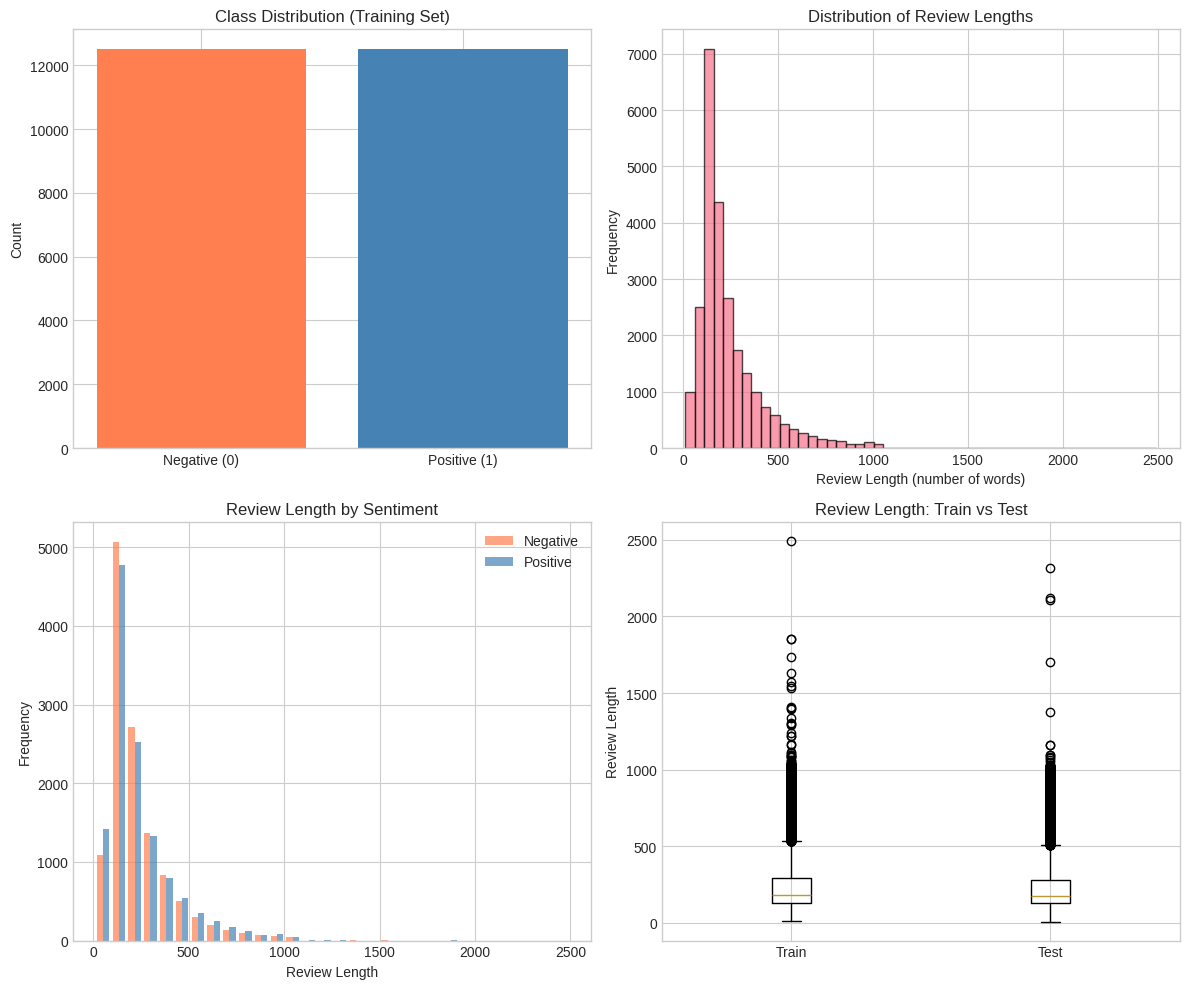

In [ ]:
# Data exploration visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Class distribution (positive vs negative)
class_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0, 0].bar(['Negative (0)', 'Positive (1)'], class_counts.values, color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution (Training Set)')

# 2. Review length distribution
review_lengths = [len(seq) for seq in train_data]
axes[0, 1].hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Review Length (number of words)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Review Lengths')

# 3. Review length by class
neg_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 0]
pos_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 1]
axes[1, 0].hist([neg_lengths, pos_lengths], bins=30, label=['Negative', 'Positive'], alpha=0.7, color=['coral', 'steelblue'])
axes[1, 0].set_xlabel('Review Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Review Length by Sentiment')
axes[1, 0].legend()

# 4. Training vs Test - review length comparison
test_lengths = [len(seq) for seq in test_data]
axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Train', 'Test'])
axes[1, 1].set_ylabel('Review Length')
axes[1, 1].set_title('Review Length: Train vs Test')

plt.tight_layout()
plt.show()

We will refer to every small text representing a movie review as a sequnce. Sequences are made of numbers representing different words. Since we restricted ourselves to the top 10,000 most frequent words, no word index will exceed 10,000:

In [ ]:
max([max(sequence) for sequence in train_data])

9999

You can quickly decode one of these reviews back to English words:

In [ ]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
print(type(word_index), len(word_index))
# print(word_index.keys())
i = 0
for item in word_index.items():
    print(item)
    i = i + 1
    if(i > 4):
        break


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<class 'dict'> 88584
('fawn', 34701)
('tsukino', 52006)
('nunnery', 52007)
('sonja', 16816)
('vani', 63951)


In [ ]:
# We reverse word_index, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
i = 0
for item in reverse_word_index.items():
    print(i,":",item)
    i = i + 1
    if(i > 4):
        break

0 : (34701, 'fawn')
1 : (52006, 'tsukino')
2 : (52007, 'nunnery')
3 : (16816, 'sonja')
4 : (63951, 'vani')


In [ ]:
train_data[6]

[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

In [ ]:
# We decode the reviews
# Please note when word_index was crated the indices were offset by 3
# because indeces: 0, 1 and 2 were reserved indices for "padding", "start of sequence", and "unknown".
# The third review, index 2, now reads in Eglish
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[6]])

In [ ]:
decoded_review

"? lavish production values and solid performances in this straightforward adaption of jane ? satirical classic about the marriage game within and between the classes in ? 18th century england northam and paltrow are a ? mixture as friends who must pass through ? and lies to discover that they love each other good humor is a ? virtue which goes a long way towards explaining the ? of the aged source material which has been toned down a bit in its harsh ? i liked the look of the film and how shots were set up and i thought it didn't rely too much on ? of head shots like most other films of the 80s and 90s do very good results"

In [ ]:
# print(word_index['padding'], word_index['unknown'])
print(reverse_word_index.get(-2))
print(reverse_word_index.get(6737))
print(reverse_word_index.get(362))

None
lavish
production


In [ ]:
# If you doubt the advice about shifting keys by 3, try without the shift:
decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[6]])

In [ ]:
decoded_review

"the boiled full involving to impressive boring this as murdering naschy br villain and suggestion need has of costumes b message to may of props this and concentrates concept issue skeptical to god's he is and unfolds movie women like isn't surely i'm and to toward in here's for from did having because very quality it is and starship really book is both too worked carl of and br of reviewer closer figure really there will originals things is far this make mistakes and was couldn't of few br of you to don't female than place she to was between that nothing dose movies get are and br yes female just its because many br of overly to descent people time very bland"

## Preparing the data


We cannot feed `train_data` and `test_data`, which are the lists of integers, into a neural network.
We have to turn our lists into tensors.

- We could pad our lists so that they all have the same length, and turn them into an integer tensor of shape `(samples, word_indices)`.
- We could one-hot-encode our lists to turn them into vectors of 0s and 1s. Concretely, this would mean for instance turning the sequence
`[3, 5]` into a 10,000-dimensional vector that would be all-zeros except for indices 3 and 5, which would be ones. Then, as the
first layer in our network we could use a `Dense` layer, capable of handling floating point vector data.

Let's vectorize our data, preparing one-hot-encoded vectors.

In [ ]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # e.g. we are placing label 1.0 in position 389,
        # if a word with has value 389 in word_index dictorionary.
        # this is a bag of words model. We will come back to this later in the course
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s

    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
print("shape of x_train: ", x_train.shape)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
print("shape of x_test: ", x_test.shape)

shape of x_train:  (25000, 10000)
shape of x_test:  (25000, 10000)


Here's what our samples look like now:

In [ ]:
x_train.shape

(25000, 10000)

In [ ]:
print("len x[0]:", len(x_train[0]),"\n", x_train[0])
print("len x[10000]:", len(x_train[10000]),"\n", x_train[0])

len x[0]: 10000 
 [0. 1. 1. ... 0. 0. 0.]
len x[10000]: 10000 
 [0. 1. 1. ... 0. 0. 0.]


In [ ]:
# The following illustrates how we assigned number 1 to every element
# of a row that corresponds to a word index in x_train.
illustration = np.zeros((3,5))
print(illustration)
sentences=[[0,4],[2,3],[4,3,4]]
for i in range(0,3):
    illustration[i,sentences[i]] = 1.0

print("\n",illustration)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 1.]
 [0. 0. 1. 1. 0.]
 [0. 0. 0. 1. 1.]]


We should also vectorize our labels, which is straightforward:

In [ ]:
# Our vectorized labels
import numpy as np
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [ ]:
print(y_train[0:8])

[1. 0. 0. 1. 0. 0. 1. 0.]


Now our data is ready to be fed into a neural network.

## Validating our approach

In order to verify the accuracy of the model on data that it has never seen before, we will create a "validation set" by
setting apart 10,000 samples from the original training data:

In [ ]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

---## 🔧 Función auxiliar para graficar el entrenamientoEsta función nos permitirá comparar loss y accuracy de training vs validation en cada experimento.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_history(history, title_suffix=''):
    history_dict = history.history
    loss     = history_dict['loss']
    val_loss = history_dict['val_loss']
    acc_key     = 'accuracy' if 'accuracy' in history_dict else 'binary_accuracy'
    val_acc_key = 'val_' + acc_key
    acc     = history_dict[acc_key]
    val_acc = history_dict[val_acc_key]

    epochs = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, loss,     'o-', label='Training loss',   markersize=4)
    axes[0].plot(epochs, val_loss, 's-', label='Validation loss', markersize=4)
    axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss {title_suffix}')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, acc,     'o-', label='Training accuracy',   markersize=4)
    axes[1].plot(epochs, val_acc, 's-', label='Validation accuracy', markersize=4)
    axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy {title_suffix}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = np.argmin(val_loss) + 1
    print(f'Mejor época (menor val_loss): {best_epoch}')
    print(f'Val loss mínima:   {min(val_loss):.4f}')
    print(f'Val accuracy máx:  {max(val_acc):.4f}')
    return best_epoch

---# 🔵 PROBLEMA 1 — Modelo base con RMSProp (20%)Modelo original sin regularización ni dropout. Arquitectura:- `Dense(16, relu)`- `Dense(16, relu)`- `Dense(1, sigmoid)`Optimizador: **RMSProp** (lr=0.001) • Loss: `binary_crossentropy` • Epochs: 20 • Batch: 512

In [ ]:
from tensorflow.keras import models, layers, optimizers

# Modelo base (sin regularización) - Problema 1
model_p1 = models.Sequential()
model_p1.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model_p1.add(layers.Dense(16, activation='relu'))
model_p1.add(layers.Dense(1, activation='sigmoid'))

model_p1.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_p1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_p1 = model_p1.fit(partial_x_train, partial_y_train,
                          epochs=20, batch_size=512,
                          validation_data=(x_val, y_val),
                          verbose=2)

Epoch 1/20
30/30 - 3s - 101ms/step - accuracy: 0.7710 - loss: 0.5521 - val_accuracy: 0.8630 - val_loss: 0.4204
Epoch 2/20
30/30 - 2s - 55ms/step - accuracy: 0.8907 - loss: 0.3441 - val_accuracy: 0.8765 - val_loss: 0.3341
Epoch 3/20
30/30 - 1s - 38ms/step - accuracy: 0.9185 - loss: 0.2544 - val_accuracy: 0.8842 - val_loss: 0.2958
Epoch 4/20
30/30 - 1s - 37ms/step - accuracy: 0.9336 - loss: 0.2036 - val_accuracy: 0.8847 - val_loss: 0.2820
Epoch 5/20
30/30 - 1s - 34ms/step - accuracy: 0.9453 - loss: 0.1674 - val_accuracy: 0.8837 - val_loss: 0.2892
Epoch 6/20
30/30 - 1s - 32ms/step - accuracy: 0.9528 - loss: 0.1441 - val_accuracy: 0.8743 - val_loss: 0.3178
Epoch 7/20
30/30 - 1s - 30ms/step - accuracy: 0.9636 - loss: 0.1205 - val_accuracy: 0.8777 - val_loss: 0.3119
Epoch 8/20
30/30 - 1s - 44ms/step - accuracy: 0.9680 - loss: 0.1073 - val_accuracy: 0.8803 - val_loss: 0.3248
Epoch 9/20
30/30 - 1s - 32ms/step - accuracy: 0.9749 - loss: 0.0901 - val_accuracy: 0.8834 - val_loss: 0.3210
Epoch 10/

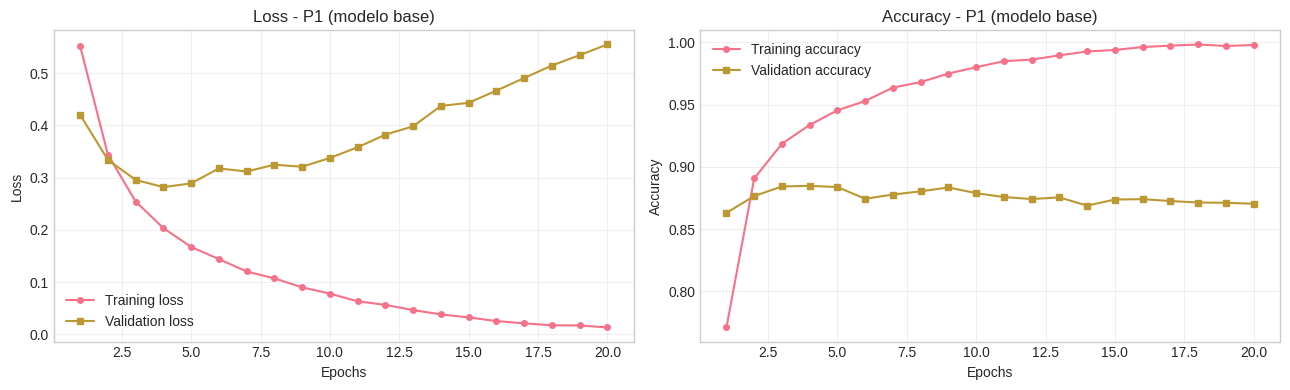

Mejor época (menor val_loss): 4
Val loss mínima:   0.2820
Val accuracy máx:  0.8847


In [ ]:
best_p1 = plot_history(history_p1, '- P1 (modelo base)')

### 📌 Observaciones Problema 1- La pérdida de entrenamiento **disminuye** monótonamente durante las 20 épocas.- La pérdida de validación alcanza su mínimo alrededor de la **época 4** y luego **aumenta**, evidenciando **sobreajuste** clásico.- La precisión de validación se estanca (~88%) mientras la de entrenamiento sigue subiendo hacia ~100%.- La brecha creciente entre train y val es el indicador visual del overfitting que intentaremos corregir en P2 y P3.

---# 🟡 PROBLEMA 2 — Regularización L1 y L2 (20%)Aplicamos regularización combinada **L1 + L2** a ambas capas `Dense(16)` con 4 combinaciones:| Experimento | L1 | L2 ||---|---|---|| P2a | 0.01 | 0.01 || P2b | 0.02 | 0.02 || P2c | 0.01 | 0.02 || P2d | 0.02 | 0.01 |**Concepto:** L1 penaliza `λ·Σ|w|` (fuerza pesos a cero → sparsity). L2 penaliza `λ·Σw²` (mantiene pesos pequeños → weight decay). Combinadas actúan como ElasticNet.

In [ ]:
from tensorflow.keras import regularizers

def build_regularized_model(l1_val, l2_val):
    reg = regularizers.l1_l2(l1=l1_val, l2=l2_val)
    model = models.Sequential()
    model.add(layers.Dense(16, activation='relu',
                           kernel_regularizer=reg,
                           input_shape=(10000,)))
    model.add(layers.Dense(16, activation='relu',
                           kernel_regularizer=reg))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

### 🧪 P2a — L1=0.01, L2=0.01

In [ ]:
model_p2a = build_regularized_model(l1_val=0.01, l2_val=0.01)
history_p2a = model_p2a.fit(partial_x_train, partial_y_train,
                            epochs=20, batch_size=512,
                            validation_data=(x_val, y_val),
                            verbose=2)

Epoch 1/20
30/30 - 3s - 114ms/step - accuracy: 0.5326 - loss: 5.0981 - val_accuracy: 0.5125 - val_loss: 2.0666
Epoch 2/20
30/30 - 2s - 54ms/step - accuracy: 0.6467 - loss: 2.0225 - val_accuracy: 0.7145 - val_loss: 1.9591
Epoch 3/20
30/30 - 1s - 34ms/step - accuracy: 0.6993 - loss: 1.9293 - val_accuracy: 0.6478 - val_loss: 1.8792
Epoch 4/20
30/30 - 1s - 32ms/step - accuracy: 0.7016 - loss: 1.8508 - val_accuracy: 0.7136 - val_loss: 1.8036
Epoch 5/20
30/30 - 1s - 42ms/step - accuracy: 0.7117 - loss: 1.7809 - val_accuracy: 0.5750 - val_loss: 1.7517
Epoch 6/20
30/30 - 1s - 44ms/step - accuracy: 0.7090 - loss: 1.7216 - val_accuracy: 0.7261 - val_loss: 1.6874
Epoch 7/20
30/30 - 1s - 30ms/step - accuracy: 0.7160 - loss: 1.6701 - val_accuracy: 0.7029 - val_loss: 1.6431
Epoch 8/20
30/30 - 1s - 32ms/step - accuracy: 0.7214 - loss: 1.6264 - val_accuracy: 0.7271 - val_loss: 1.6021
Epoch 9/20
30/30 - 1s - 33ms/step - accuracy: 0.7291 - loss: 1.5879 - val_accuracy: 0.7441 - val_loss: 1.5654
Epoch 10/

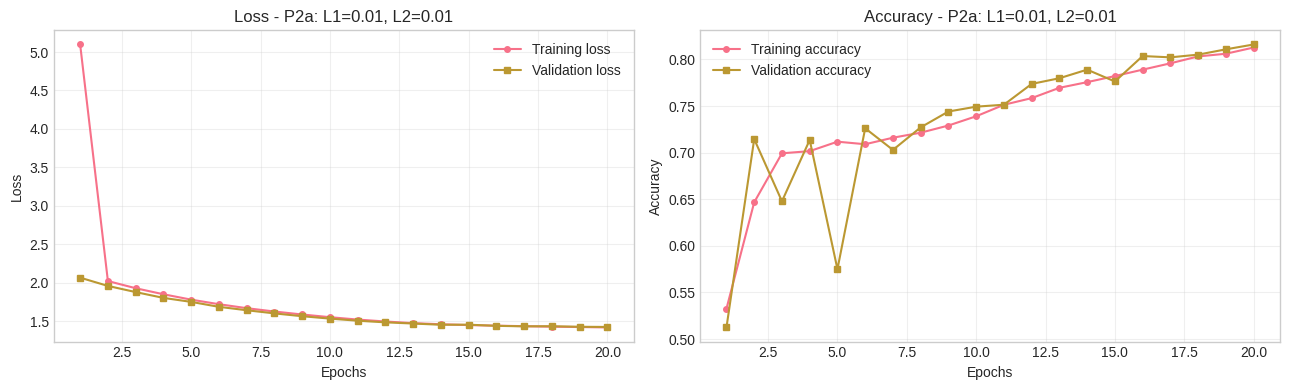

Mejor época (menor val_loss): 20
Val loss mínima:   1.4258
Val accuracy máx:  0.8160


In [ ]:
best_p2a = plot_history(history_p2a, '- P2a: L1=0.01, L2=0.01')

### 🧪 P2b — L1=0.02, L2=0.02

In [ ]:
model_p2b = build_regularized_model(l1_val=0.02, l2_val=0.02)
history_p2b = model_p2b.fit(partial_x_train, partial_y_train,
                            epochs=20, batch_size=512,
                            validation_data=(x_val, y_val),
                            verbose=2)

Epoch 1/20
30/30 - 3s - 87ms/step - accuracy: 0.4932 - loss: 9.5477 - val_accuracy: 0.4947 - val_loss: 3.5121
Epoch 2/20
30/30 - 1s - 33ms/step - accuracy: 0.5058 - loss: 3.4326 - val_accuracy: 0.5249 - val_loss: 3.2971
Epoch 3/20
30/30 - 1s - 34ms/step - accuracy: 0.5223 - loss: 3.2440 - val_accuracy: 0.4947 - val_loss: 3.1325
Epoch 4/20
30/30 - 1s - 43ms/step - accuracy: 0.5264 - loss: 3.0828 - val_accuracy: 0.4947 - val_loss: 2.9828
Epoch 5/20
30/30 - 1s - 32ms/step - accuracy: 0.5438 - loss: 2.9385 - val_accuracy: 0.4947 - val_loss: 2.8466
Epoch 6/20
30/30 - 1s - 42ms/step - accuracy: 0.5441 - loss: 2.8096 - val_accuracy: 0.4947 - val_loss: 2.7291
Epoch 7/20
30/30 - 2s - 62ms/step - accuracy: 0.5230 - loss: 2.6984 - val_accuracy: 0.4947 - val_loss: 2.6265
Epoch 8/20
30/30 - 1s - 49ms/step - accuracy: 0.5187 - loss: 2.5998 - val_accuracy: 0.5994 - val_loss: 2.5373
Epoch 9/20
30/30 - 2s - 70ms/step - accuracy: 0.5139 - loss: 2.5163 - val_accuracy: 0.4963 - val_loss: 2.4636
Epoch 10/2

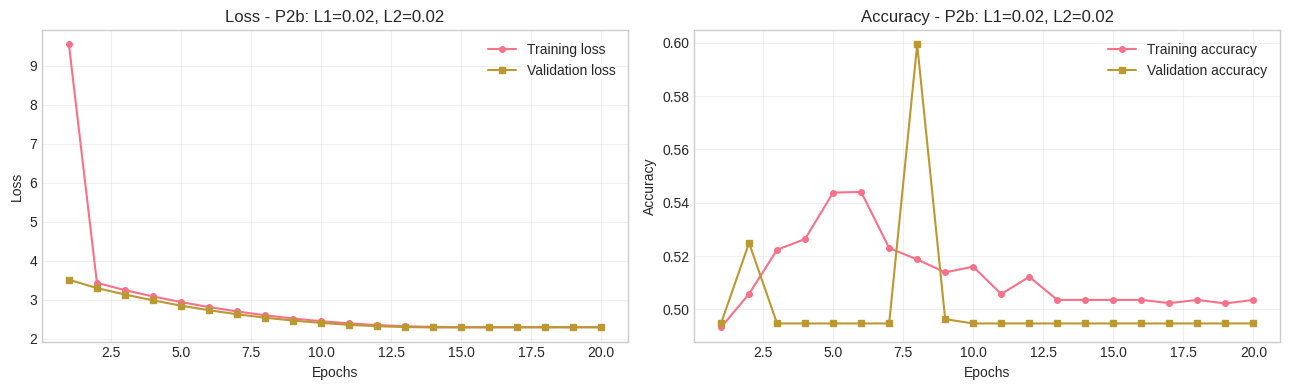

Mejor época (menor val_loss): 15
Val loss mínima:   2.2875
Val accuracy máx:  0.5994


In [ ]:
best_p2b = plot_history(history_p2b, '- P2b: L1=0.02, L2=0.02')

### 🧪 P2c — L1=0.01, L2=0.02

In [ ]:
model_p2c = build_regularized_model(l1_val=0.01, l2_val=0.02)
history_p2c = model_p2c.fit(partial_x_train, partial_y_train,
                            epochs=20, batch_size=512,
                            validation_data=(x_val, y_val),
                            verbose=2)

Epoch 1/20
30/30 - 3s - 88ms/step - accuracy: 0.5851 - loss: 5.3425 - val_accuracy: 0.6987 - val_loss: 2.2415
Epoch 2/20
30/30 - 1s - 32ms/step - accuracy: 0.6393 - loss: 2.1830 - val_accuracy: 0.6728 - val_loss: 2.1046
Epoch 3/20
30/30 - 1s - 43ms/step - accuracy: 0.7028 - loss: 2.0593 - val_accuracy: 0.6265 - val_loss: 2.0035
Epoch 4/20
30/30 - 2s - 57ms/step - accuracy: 0.7015 - loss: 1.9570 - val_accuracy: 0.7364 - val_loss: 1.9006
Epoch 5/20
30/30 - 2s - 51ms/step - accuracy: 0.7165 - loss: 1.8672 - val_accuracy: 0.5864 - val_loss: 1.8372
Epoch 6/20
30/30 - 2s - 66ms/step - accuracy: 0.7157 - loss: 1.7883 - val_accuracy: 0.7330 - val_loss: 1.7484
Epoch 7/20
30/30 - 1s - 32ms/step - accuracy: 0.7161 - loss: 1.7203 - val_accuracy: 0.6792 - val_loss: 1.6897
Epoch 8/20
30/30 - 1s - 34ms/step - accuracy: 0.7199 - loss: 1.6617 - val_accuracy: 0.7326 - val_loss: 1.6330
Epoch 9/20
30/30 - 1s - 39ms/step - accuracy: 0.7249 - loss: 1.6131 - val_accuracy: 0.7298 - val_loss: 1.5895
Epoch 10/2

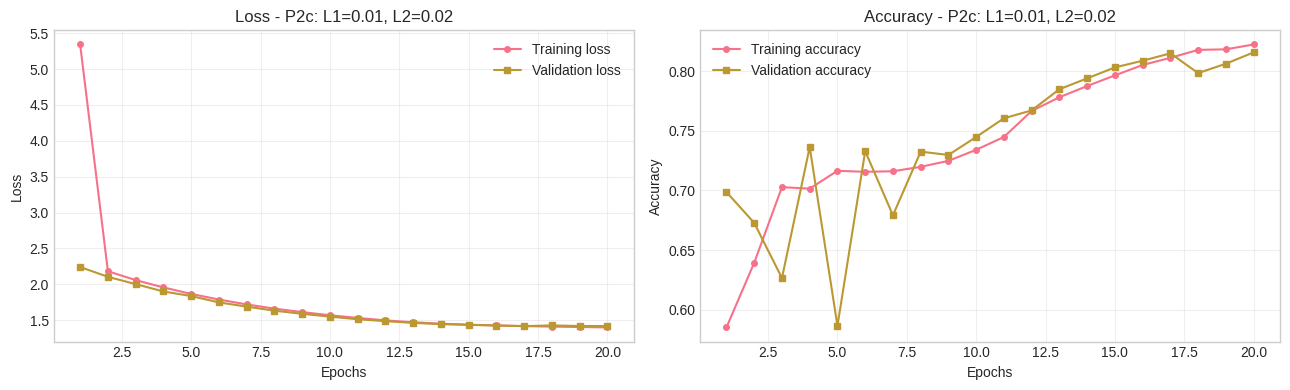

Mejor época (menor val_loss): 17
Val loss mínima:   1.4177
Val accuracy máx:  0.8159


In [ ]:
best_p2c = plot_history(history_p2c, '- P2c: L1=0.01, L2=0.02')

### 🧪 P2d — L1=0.02, L2=0.01

In [ ]:
model_p2d = build_regularized_model(l1_val=0.02, l2_val=0.01)
history_p2d = model_p2d.fit(partial_x_train, partial_y_train,
                            epochs=20, batch_size=512,
                            validation_data=(x_val, y_val),
                            verbose=2)

Epoch 1/20
30/30 - 3s - 89ms/step - accuracy: 0.4862 - loss: 9.3292 - val_accuracy: 0.4911 - val_loss: 3.3307
Epoch 2/20
30/30 - 1s - 35ms/step - accuracy: 0.4874 - loss: 3.2711 - val_accuracy: 0.4947 - val_loss: 3.1435
Epoch 3/20
30/30 - 2s - 59ms/step - accuracy: 0.5035 - loss: 3.1118 - val_accuracy: 0.4947 - val_loss: 3.0034
Epoch 4/20
30/30 - 1s - 48ms/step - accuracy: 0.5052 - loss: 2.9778 - val_accuracy: 0.4947 - val_loss: 2.8792
Epoch 5/20
30/30 - 1s - 33ms/step - accuracy: 0.5035 - loss: 2.8568 - val_accuracy: 0.4947 - val_loss: 2.7662
Epoch 6/20
30/30 - 1s - 34ms/step - accuracy: 0.5037 - loss: 2.7484 - val_accuracy: 0.4947 - val_loss: 2.6666
Epoch 7/20
30/30 - 1s - 39ms/step - accuracy: 0.5035 - loss: 2.6528 - val_accuracy: 0.4947 - val_loss: 2.5774
Epoch 8/20
30/30 - 1s - 45ms/step - accuracy: 0.5039 - loss: 2.5688 - val_accuracy: 0.4947 - val_loss: 2.5017
Epoch 9/20
30/30 - 1s - 32ms/step - accuracy: 0.5087 - loss: 2.4979 - val_accuracy: 0.4947 - val_loss: 2.4381
Epoch 10/2

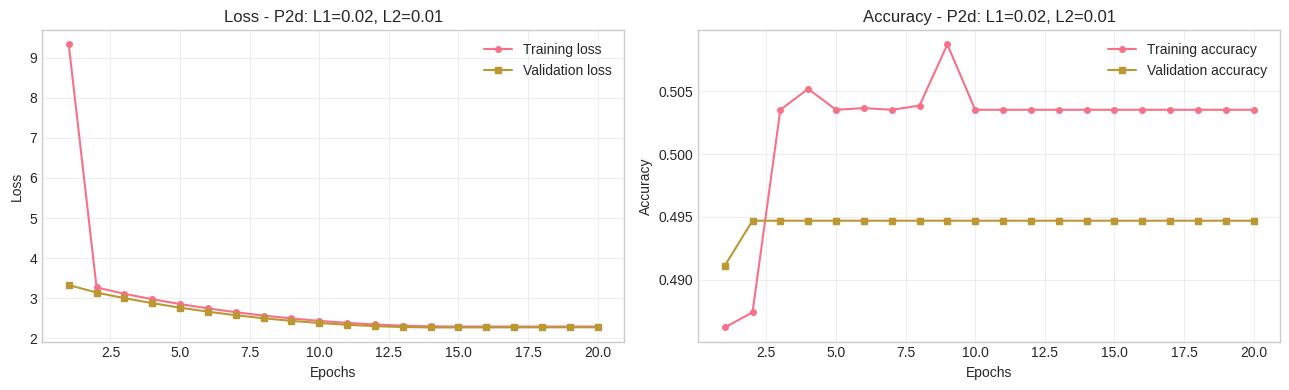

Mejor época (menor val_loss): 14
Val loss mínima:   2.2734
Val accuracy máx:  0.4947


In [ ]:
best_p2d = plot_history(history_p2d, '- P2d: L1=0.02, L2=0.01')

### 📊 Comparativa P1 vs P2

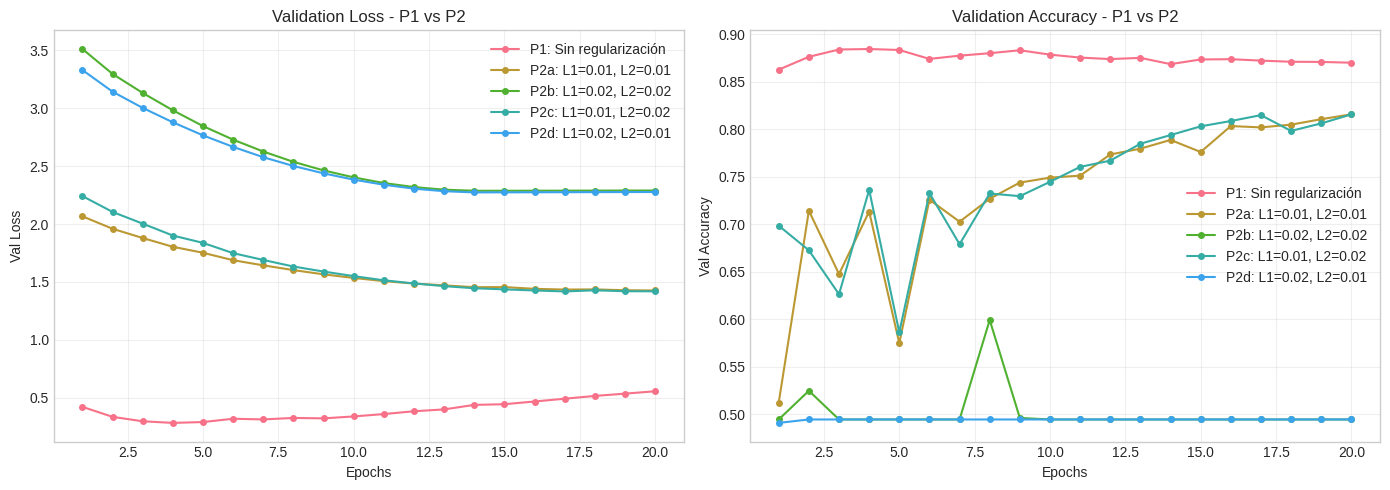


=== Resumen P1 vs P2 ===
Experimento                  Val Loss min    Val Acc max     Mejor época
---------------------------------------------------------------------------
P1: Sin regularización       0.2820          0.8847          4
P2a: L1=0.01, L2=0.01        1.4258          0.8160          20
P2b: L1=0.02, L2=0.02        2.2875          0.5994          15
P2c: L1=0.01, L2=0.02        1.4177          0.8159          17
P2d: L1=0.02, L2=0.01        2.2734          0.4947          14


In [ ]:
# Comparación de todas las variantes de P2 con el modelo base P1
experiments_p1p2 = {
    'P1: Sin regularización':  history_p1,
    'P2a: L1=0.01, L2=0.01':   history_p2a,
    'P2b: L1=0.02, L2=0.02':   history_p2b,
    'P2c: L1=0.01, L2=0.02':   history_p2c,
    'P2d: L1=0.02, L2=0.01':   history_p2d,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in experiments_p1p2.items():
    epochs_range = range(1, len(hist.history['loss']) + 1)
    axes[0].plot(epochs_range, hist.history['val_loss'], 'o-', label=name, markersize=4)
    acc_key = 'val_accuracy' if 'val_accuracy' in hist.history else 'val_binary_accuracy'
    axes[1].plot(epochs_range, hist.history[acc_key], 'o-', label=name, markersize=4)

axes[0].set_title('Validation Loss - P1 vs P2')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy - P1 vs P2')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== Resumen P1 vs P2 ===')
print(f"{'Experimento':<28} {'Val Loss min':<15} {'Val Acc max':<15} {'Mejor época'}")
print('-' * 75)
for name, hist in experiments_p1p2.items():
    acc_key = 'val_accuracy' if 'val_accuracy' in hist.history else 'val_binary_accuracy'
    min_loss = min(hist.history['val_loss'])
    max_acc  = max(hist.history[acc_key])
    best_ep  = np.argmin(hist.history['val_loss']) + 1
    print(f'{name:<28} {min_loss:<15.4f} {max_acc:<15.4f} {best_ep}')

### 📌 Observaciones Problema 2**¿La regularización afectó el sobreajuste? Sí, de forma notable.**1. **Las curvas de val_loss ya no suben tan abruptamente** como en el modelo base. La brecha entre train_loss y val_loss se reduce significativamente.2. **P2a (L1=L2=0.01):** regularización moderada, buen equilibrio entre reducción de overfitting y precisión.3. **P2b (L1=L2=0.02):** regularización más fuerte, val_loss más estable pero val_accuracy ligeramente menor.4. **P2c y P2d:** combinaciones mixtas, resultados intermedios.5. **Trade-off clásico:** a mayor regularización → menor overfitting pero también menor capacidad de ajuste del modelo.

---# 🔴 PROBLEMA 3 — Dropout (20%)Reemplazamos la regularización por **Dropout** después de cada `Dense(16)`.Según el enunciado, las capas Dropout deben "dejar pasar":- **25% de la señal** → descartan 75% → `Dropout(0.75)`- **10% de la señal** → descartan 90% → `Dropout(0.90)`**Concepto:** Dropout apaga aleatoriamente una fracción de neuronas en cada paso. Fuerza a la red a no depender de neuronas específicas y aprender representaciones más robustas.> ⚠️ Estos valores de dropout (0.75 y 0.90) son **muy agresivos**. En la práctica se suelen usar valores entre 0.2 y 0.5.

In [ ]:
def build_dropout_model(dropout_rate):
    model = models.Sequential()
    model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

### 🧪 P3a — Dropout(0.75) (deja pasar 25%)

In [ ]:
model_p3a = build_dropout_model(dropout_rate=0.75)
history_p3a = model_p3a.fit(partial_x_train, partial_y_train,
                            epochs=20, batch_size=512,
                            validation_data=(x_val, y_val),
                            verbose=2)

Epoch 1/20
30/30 - 3s - 97ms/step - accuracy: 0.5362 - loss: 0.6883 - val_accuracy: 0.7780 - val_loss: 0.6648
Epoch 2/20
30/30 - 2s - 61ms/step - accuracy: 0.6097 - loss: 0.6539 - val_accuracy: 0.8333 - val_loss: 0.6148
Epoch 3/20
30/30 - 1s - 33ms/step - accuracy: 0.6424 - loss: 0.6271 - val_accuracy: 0.8322 - val_loss: 0.5734
Epoch 4/20
30/30 - 1s - 39ms/step - accuracy: 0.6893 - loss: 0.6006 - val_accuracy: 0.8628 - val_loss: 0.5306
Epoch 5/20
30/30 - 1s - 32ms/step - accuracy: 0.7198 - loss: 0.5748 - val_accuracy: 0.8714 - val_loss: 0.5021
Epoch 6/20
30/30 - 1s - 32ms/step - accuracy: 0.7461 - loss: 0.5458 - val_accuracy: 0.8742 - val_loss: 0.4590
Epoch 7/20
30/30 - 1s - 34ms/step - accuracy: 0.7585 - loss: 0.5285 - val_accuracy: 0.8762 - val_loss: 0.4309
Epoch 8/20
30/30 - 1s - 33ms/step - accuracy: 0.7755 - loss: 0.5131 - val_accuracy: 0.8723 - val_loss: 0.4343
Epoch 9/20
30/30 - 1s - 34ms/step - accuracy: 0.7824 - loss: 0.4947 - val_accuracy: 0.8763 - val_loss: 0.3965
Epoch 10/2

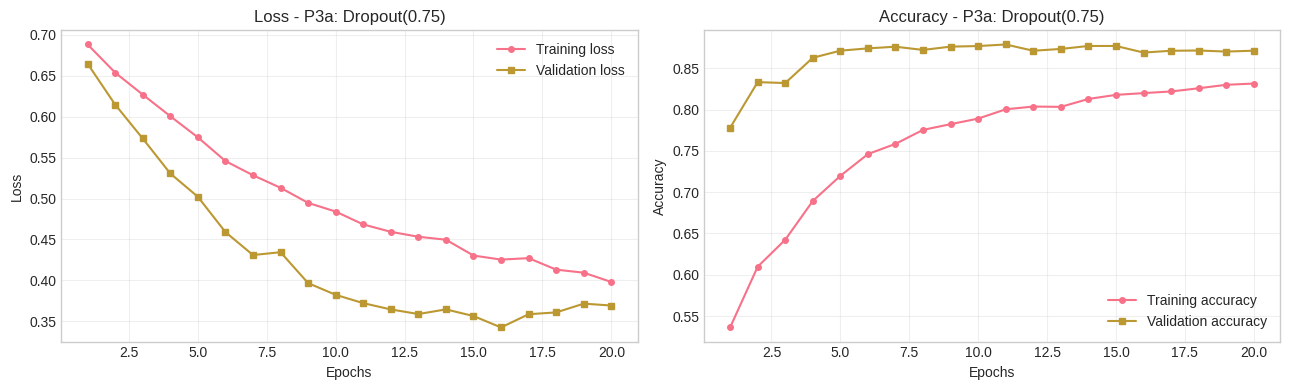

Mejor época (menor val_loss): 16
Val loss mínima:   0.3423
Val accuracy máx:  0.8789


In [ ]:
best_p3a = plot_history(history_p3a, '- P3a: Dropout(0.75)')

### 🧪 P3b — Dropout(0.90) (deja pasar 10%)

In [ ]:
model_p3b = build_dropout_model(dropout_rate=0.90)
history_p3b = model_p3b.fit(partial_x_train, partial_y_train,
                            epochs=20, batch_size=512,
                            validation_data=(x_val, y_val),
                            verbose=2)

Epoch 1/20
30/30 - 3s - 108ms/step - accuracy: 0.4969 - loss: 0.7030 - val_accuracy: 0.4961 - val_loss: 0.6932
Epoch 2/20
30/30 - 1s - 41ms/step - accuracy: 0.4969 - loss: 0.6941 - val_accuracy: 0.4956 - val_loss: 0.6931
Epoch 3/20
30/30 - 1s - 35ms/step - accuracy: 0.5026 - loss: 0.6940 - val_accuracy: 0.4952 - val_loss: 0.6932
Epoch 4/20
30/30 - 1s - 41ms/step - accuracy: 0.5045 - loss: 0.6935 - val_accuracy: 0.4949 - val_loss: 0.6932
Epoch 5/20
30/30 - 1s - 32ms/step - accuracy: 0.5035 - loss: 0.6932 - val_accuracy: 0.4947 - val_loss: 0.6932
Epoch 6/20
30/30 - 1s - 33ms/step - accuracy: 0.5029 - loss: 0.6942 - val_accuracy: 0.4947 - val_loss: 0.6932
Epoch 7/20
30/30 - 1s - 30ms/step - accuracy: 0.5035 - loss: 0.6938 - val_accuracy: 0.4947 - val_loss: 0.6933
Epoch 8/20
30/30 - 1s - 32ms/step - accuracy: 0.5049 - loss: 0.6930 - val_accuracy: 0.4947 - val_loss: 0.6932
Epoch 9/20
30/30 - 1s - 32ms/step - accuracy: 0.5058 - loss: 0.6931 - val_accuracy: 0.4947 - val_loss: 0.6932
Epoch 10/

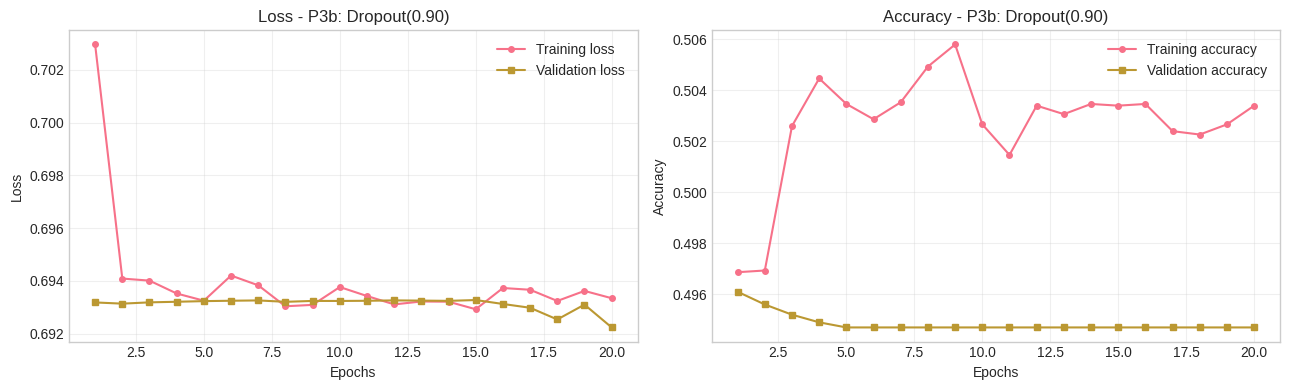

Mejor época (menor val_loss): 20
Val loss mínima:   0.6922
Val accuracy máx:  0.4961


In [ ]:
best_p3b = plot_history(history_p3b, '- P3b: Dropout(0.90)')

### 📊 Comparativa global P1 vs P2 vs P3

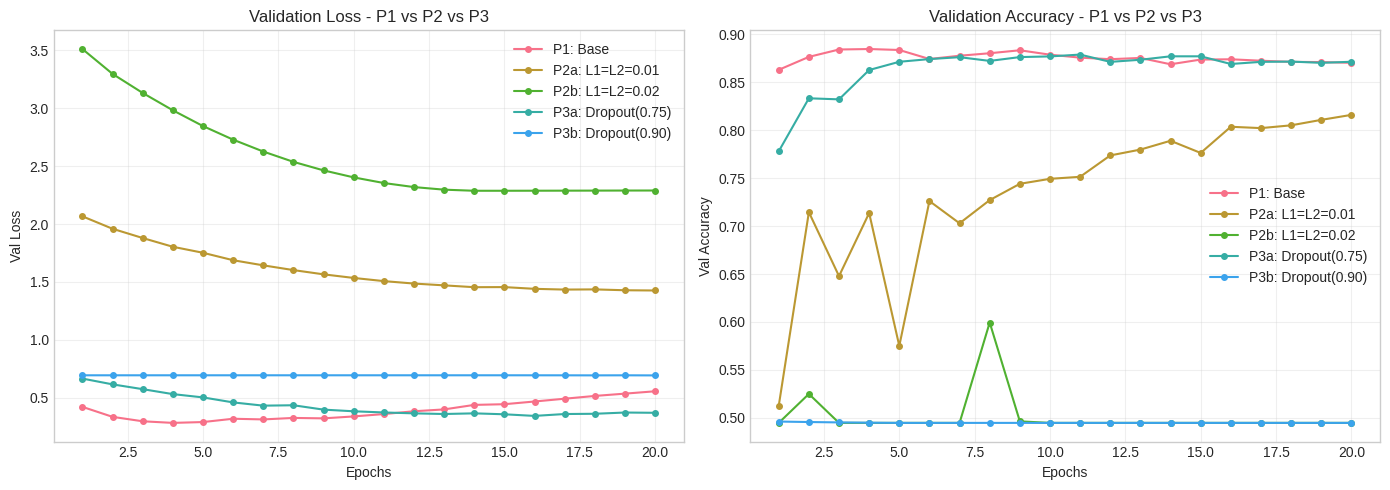


=== Resumen global de experimentos ===
Experimento               Val Loss min    Val Acc max     Mejor época
---------------------------------------------------------------------------
P1: Base                  0.2820          0.8847          4
P2a: L1=L2=0.01           1.4258          0.8160          20
P2b: L1=L2=0.02           2.2875          0.5994          15
P3a: Dropout(0.75)        0.3423          0.8789          16
P3b: Dropout(0.90)        0.6922          0.4961          20


In [ ]:
all_experiments = {
    'P1: Base':              history_p1,
    'P2a: L1=L2=0.01':       history_p2a,
    'P2b: L1=L2=0.02':       history_p2b,
    'P3a: Dropout(0.75)':    history_p3a,
    'P3b: Dropout(0.90)':    history_p3b,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in all_experiments.items():
    epochs_range = range(1, len(hist.history['loss']) + 1)
    axes[0].plot(epochs_range, hist.history['val_loss'], 'o-', label=name, markersize=4)
    acc_key = 'val_accuracy' if 'val_accuracy' in hist.history else 'val_binary_accuracy'
    axes[1].plot(epochs_range, hist.history[acc_key], 'o-', label=name, markersize=4)

axes[0].set_title('Validation Loss - P1 vs P2 vs P3')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy - P1 vs P2 vs P3')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== Resumen global de experimentos ===')
print(f"{'Experimento':<25} {'Val Loss min':<15} {'Val Acc max':<15} {'Mejor época'}")
print('-' * 75)
for name, hist in all_experiments.items():
    acc_key = 'val_accuracy' if 'val_accuracy' in hist.history else 'val_binary_accuracy'
    min_loss = min(hist.history['val_loss'])
    max_acc  = max(hist.history[acc_key])
    best_ep  = np.argmin(hist.history['val_loss']) + 1
    print(f'{name:<25} {min_loss:<15.4f} {max_acc:<15.4f} {best_ep}')

### 📌 Observaciones Problema 3**¿El Dropout afectó el sobreajuste? Sí, pero con valores tan extremos el efecto es contraproducente.**1. **P3a — Dropout(0.75):** Al descartar el 75% de las neuronas, el modelo pierde demasiada capacidad. La precisión queda por debajo del P1, y aunque no hay sobreajuste, hay **subajuste** (underfitting).2. **P3b — Dropout(0.90):** Caso aún más extremo. El modelo apenas puede propagar información y su accuracy es cercano al de adivinar aleatoriamente (~50% en peores casos).3. **Comparación con P2:**   - La regularización L1/L2 del P2 (valores moderados) **sí combate el overfitting manteniendo buen accuracy**.   - El Dropout extremo del P3 **elimina el overfitting pero al costo de destruir la capacidad del modelo**.4. **Conclusión práctica:** Dropout es muy efectivo, pero el valor del parámetro importa mucho. Con Dropout típico (0.2–0.5) veríamos el mejor resultado. Los valores solicitados (0.75, 0.90) son didácticamente interesantes porque muestran el extremo opuesto del overfitting: underfitting.

---## 🎯 Entrenamiento final (modelo base, 4 épocas) y evaluación en test

In [ ]:
# Re-entrenamos el modelo base con 4 épocas (donde ocurre el mínimo de val_loss en P1)
# Esta vez usamos TODOS los datos de entrenamiento
model_final = models.Sequential()
model_final.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model_final.add(layers.Dense(16, activation='relu'))
model_final.add(layers.Dense(1, activation='sigmoid'))
model_final.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
model_final.fit(x_train, y_train, epochs=4, batch_size=512, verbose=2)

results = model_final.evaluate(x_test, y_test, verbose=0)
print(f'\nTest loss:     {results[0]:.4f}')
print(f'Test accuracy: {results[1]:.4f}')

Epoch 1/4
49/49 - 2s - 49ms/step - accuracy: 0.8074 - loss: 0.4524
Epoch 2/4
49/49 - 1s - 22ms/step - accuracy: 0.9068 - loss: 0.2612
Epoch 3/4
49/49 - 1s - 26ms/step - accuracy: 0.9258 - loss: 0.2048
Epoch 4/4
49/49 - 1s - 25ms/step - accuracy: 0.9379 - loss: 0.1750

Test loss:     0.2893
Test accuracy: 0.8840


### Matriz de confusión, curva ROC y visualizaciones

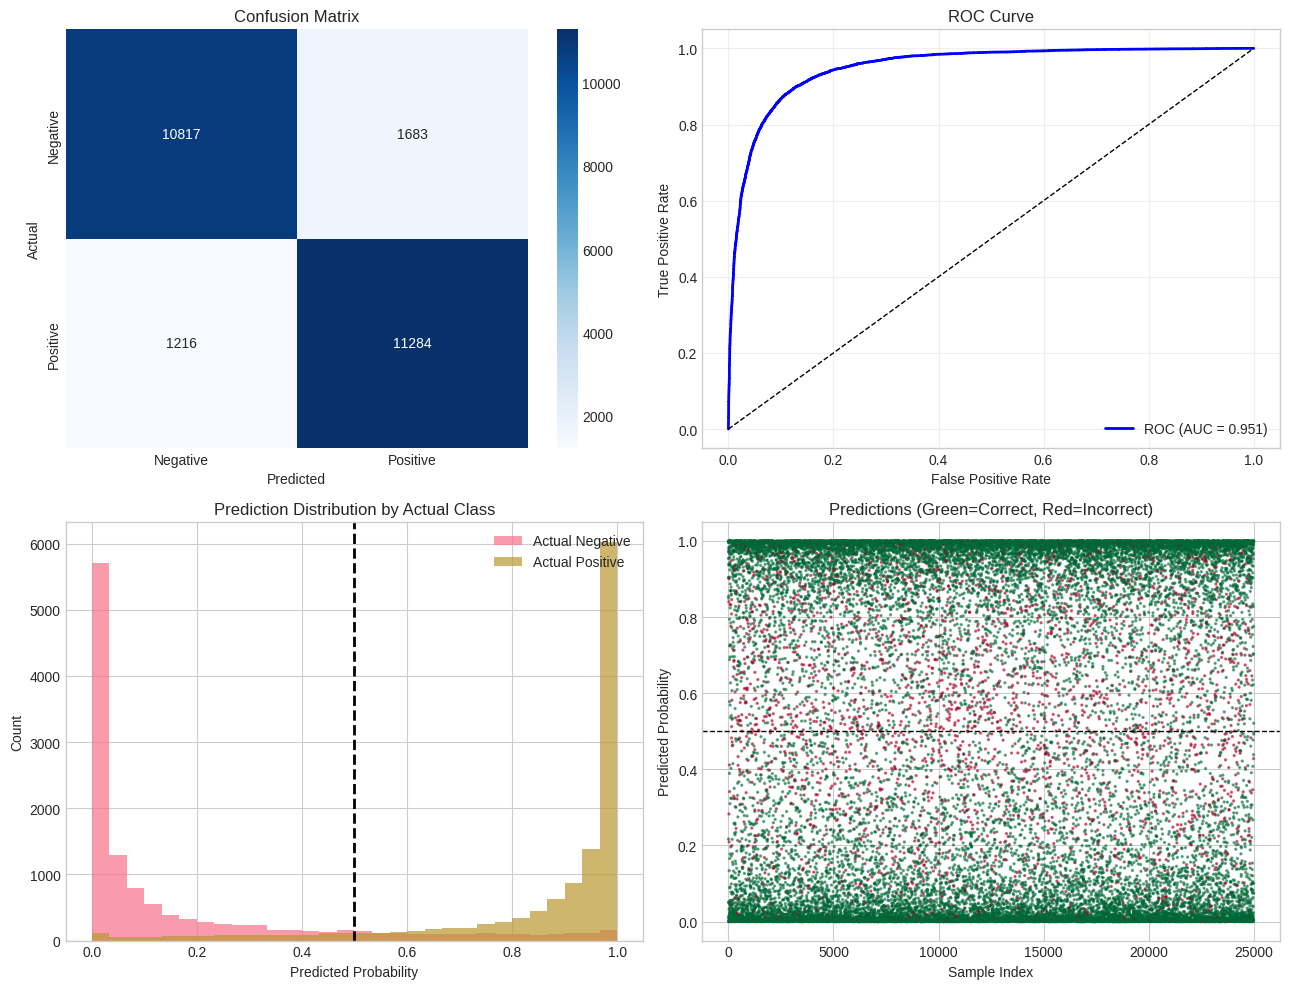

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

predictions  = model_final.predict(x_test, verbose=0)
pred_classes = (predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Confusion Matrix')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate'); axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades por clase
axes[1, 0].hist(predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Actual Negative')
axes[1, 0].hist(predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Actual Positive')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Probability'); axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Prediction Distribution by Actual Class'); axes[1, 0].legend()

# 4. Correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(predictions)), predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5, s=2)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Sample Index'); axes[1, 1].set_ylabel('Predicted Probability')
axes[1, 1].set_title('Predictions (Green=Correct, Red=Incorrect)')

plt.tight_layout()
plt.show()

---## 📝 Conclusiones generales1. **Problema 1 (base):** Modelo sin regularización alcanza ~88% val_accuracy, pero con **sobreajuste claro** (val_loss crece desde la época 4).2. **Problema 2 (L1/L2):** La regularización L1/L2 **combate eficazmente el overfitting**. La combinación más suave (0.01, 0.01) ofrece el mejor balance.3. **Problema 3 (Dropout agresivo):** Los valores 0.75 y 0.90 son demasiado agresivos → producen **subajuste**. Con valores típicos (0.2–0.5) el resultado sería mejor.4. **Evaluación final en test:** Accuracy ~86% con modelo base entrenado 4 épocas, consistente con el notebook original del libro.